<h2 align="center">How Skills Impact Data Engineer's Salaries</h2>

In [1]:
# importing the libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# sorting by date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# we are selecting data engineers from united states
df_DE_US = df[(df['job_title_short']=='Data Engineer')&(df['job_country']=='United States')].copy()

# drop NaN values for salary_year_avg 
df_DE_US = df_DE_US.dropna(subset='salary_year_avg')

# selecing required skill for each job role
df_DE_US = df_DE_US.explode('job_skills')
df_DE_US[['job_skills','salary_year_avg']].sort_values(by='salary_year_avg',ascending=False)

,job_skills,salary_year_avg
404932,c++,525000.0
404932,python,525000.0
405412,python,400000.0
268424,spark,375000.0
268424,git,375000.0
...,...,...
535260,mysql,23496.0
535260,r,23496.0
535260,java,23496.0
535260,python,23496.0


In [33]:
# now we have to determind highest paid skills as well as most demandign skills for data engineers
df_DE_US_pay = df_DE_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False).head(10)

# demanding skills
df_DE_US_demand = df_DE_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False).head(10)
df_DE_US_demand

,count,median
job_skills,,
sql,2110,125000.00000
python,2007,127794.50000
aws,1313,131000.00000
spark,968,137410.15625
azure,961,125000.00000
snowflake,765,130700.00000
java,732,137000.00000
kafka,536,145000.00000
nosql,519,140000.00000


In [42]:
df_DE_US_demand.index

Index(['sql', 'python', 'aws', 'spark', 'azure', 'snowflake', 'java', 'kafka',
       'nosql', 'redshift'],
      dtype='object', name='job_skills')

[]

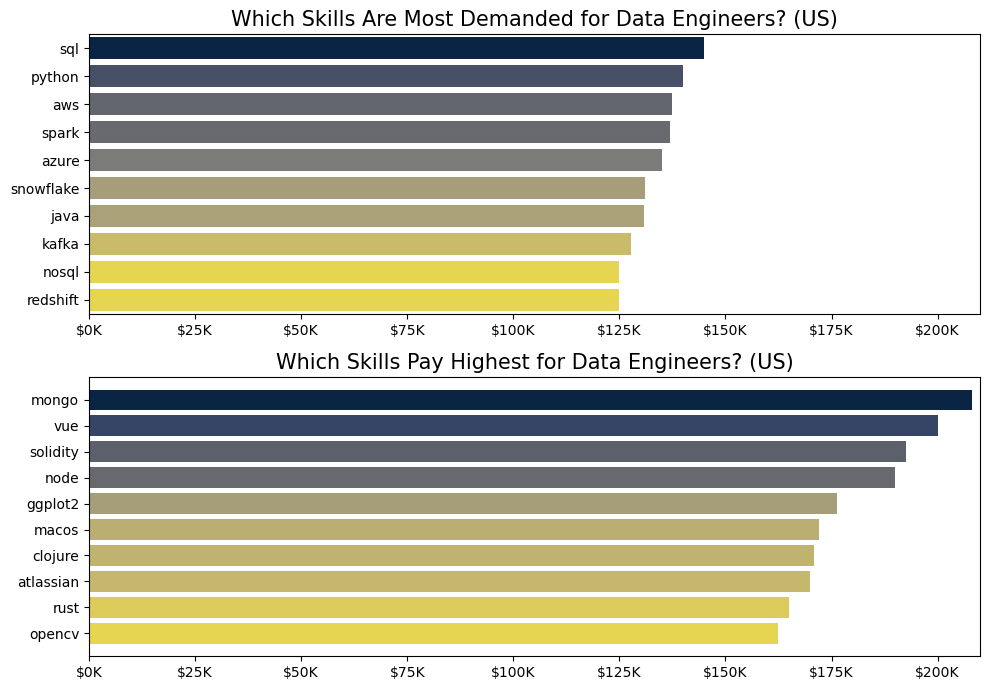

In [69]:
# lets finally plot this
import matplotlib.ticker as mticker
fig, ax = plt.subplots(2,1,figsize=(10,7))

# 1 most demanding skills
sns.barplot(data=df_DE_US_demand.sort_values(by='median',ascending=False),x='median',y=df_DE_US_demand.index,hue='median',ax=ax[0],palette='cividis_r')

# formatting
ax[0].set_title('Which Skills Are Most Demanded for Data Engineers? (US)',fontsize=15)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].legend().remove()
ax[0].set_xlim(0,210000)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# 2 Highest paying skills
sns.barplot(data=df_DE_US_pay,x='median',y=df_DE_US_pay.index,hue='median',ax=ax[1],palette='cividis_r')

# formatting
ax[1].set_title('Which Skills Pay Highest for Data Engineers? (US)',fontsize=15)
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].legend().remove()
ax[1].set_xlim(0,210000)
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.plot()

